Date: 2nd August 2026

Author: Bipul Pandey

Objectives: To take through the creation of Entropic Scales:

    In this notebook, we will go through:
        1. Jenks Fisher based entropic scale creation. 
            - This uses Jenks Fisher Partition as well as Overlap test and elbow tests
        2. Kernel Density Estimation based entropic scales creation


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import seaborn as sns

import sys

sys.path.append("../Scripts/")
from Hierarchy_construction import *


print("="*30 ,"Options:", "="*30)
print("     1 : Toy model of evolution")
print("     2: Images- MNIST")
print("     3: Sentences - Animal Simple Wikipedia")
print("     4: Sentences - Alice in Wonderland")
print("     5: Protein - Chorismate Mutase")
print("="*70)

============================== Options: ==============================
     1 : Toy model of evolution
     2: Images- MNIST
     3: Sentences - Animal Simple Wikipedia
     4: Sentences - Alice in Wonderland
     5: Protein - Chorismate Mutase


In [5]:
Experiment = 5

Experiment = int(Experiment)

if Experiment ==1:
    print("Population Toy Model")
    Data_loc = "../../Training_Data/Toy_Model_Evolution/Training_Data_Final_5000_Ground_Truth_Population.csv"
    Gen_loc = "../../Results/Generated_Data/Toy_Model_Evolution/LRBM_Generated_Population.csv"
    Model_loc = "../../Model_Parameters/Toy_Model_Evolution_LRBM_Toy/"
    Compress_Alphabets = False

elif Experiment ==2:
    print("MNIST")
    Data_loc =  "../../Training_Data/Images_MNIST/Training_Data_MNIST_Binarized_500_images.csv"
    Gen_loc = "../../Results/Generated_Data/Images_MNIST/LRBM_Generated_MNIST_Images.csv"
    Model_loc ="../../Model_Parameters/Images_LRBM_MNIST/"
    Compress_Alphabets = False

elif Experiment == 3:
    print("Sentences- Animal:Simple Wikipedia")
    Data_loc = "../../Training_Data/Sentences_Wiki/Training_Data_Wiki_1589_Tokenized_Sentences.csv"
    Gen_loc = "../../Results/Generated_Data/Sentences_Wiki/LRBM_Generated_Wiki_Sentences.csv"
    Model_loc =  "../../Model_Parameters/Sentences_LRBM_Wiki/"
    Compress_Alphabets = True

elif Experiment ==4:
    print("Sentences - Alice in Wonderland")
    Data_loc ="../../Training_Data/Sentences_Alice/Training_Data_Alice_716_Tokenized_Sentences.csv"
    Gen_loc = "../../Results/Generated_Data/Sentences_Alice/LRBM_Generated_Alice_Sentences.csv"
    Model_loc =  "../../Model_Parameters/Sentences_LRBM_Alice/"
    Compress_Alphabets = True

else:
    Experiment == 5
    print("Protein : Chorismate Mutase")
    Data_loc = "../../Training_Data/Protien_Chorismate_Mutase/Training_Data_Natural_1130_Chorismate_Mutase.csv"
    Gen_loc = "../../Results/Generated_Data/Protein_Chorismate_Mutase/LRBM_Generated_Chorismate_Mutase.csv"
    Model_loc =  "../../Model_Parameters/Proteins_LRBM_CM/"
    Compress_Alphabets = False


Protein : Chorismate Mutase


In [6]:
## Loading Training Data: ---
Training_Dataset = pd.read_csv(Data_loc)

Columns = Training_Dataset.columns
Postion_Columns=[]
for c in Columns:
    if c[0:3] == "Pos":
        Postion_Columns.append(c)
print("Number of Positions=", len(Postion_Columns))
Compact_Training_Dataset = np.array(Training_Dataset[Postion_Columns])

## Loading Generated Data: ---
Gen_Dataset = pd.read_csv(Gen_loc)
Compact_LRBM_Generated_Dataset = np.array(Gen_Dataset[Postion_Columns])
##------------

## ----Loading Scales ----
Entropic_Partition_Map = np.loadtxt(Model_loc+"Entropic_Scales_Partition_Map.txt")

Number of Positions= 96


In [8]:
### 
## In the beginning we can give some random number as number of clusters
Starting_num_scale = 5
Minimum_features_in_each_scale = 2

Hierarchy = Hierarchy_Analysis(Compact_Data=Compact_Training_Dataset, Number_of_clusters= Starting_num_scale, Min_partition_size=Minimum_features_in_each_scale)

Any Entropic Scale with less than 2 features will be combined with the nearest scale.


_________
### 1. Using Jenks-Fisher Partition to find appropriate nunber of clusters:

Bootstrap (random subsampling) based method that finds the GVF values for various number of scales and tests for the overlap between the GVF distributions to finalize an appropriate number of scales

    This requires:
            - Smallest number of scales to be tested
            - Largest number of scales to be testes
            - Proportion of Population used in each bootstrap
            - Total number of trials to be performed
            - Sigma (deviation) overlap between two adjacent GVF distributions that causes the overlap trigger
___________

In [118]:
Smallest_num_scales_tested = 2
Largest_num_scales_tested = 8
Proportion_of_Population_used = 0.4
Num_Trials = 100
Overlap_window = 1

In [119]:
GVF_Array, num_scales, Overlap_Partition_Map = Hierarchy.Jenks_GVF_Bootstrap(Smallest_num_scales_tested,
                                                      Largest_num_scales_tested,
                                                      Proportion_of_Population_used,
                                                      Num_Trials,
                                                      Overlap_window)

(7, 100)


100%|██████████| 100/100 [00:26<00:00,  3.73it/s]

Appropriate number of clusters from Elbow= 4
Elbow test Passed, overlap test didn't.
Compensating elbow scale by 1
Appropriate number of clusters from Overlap = 7
Returning- dictionary containing GVF Bootstraps for various cluster numbers and appropriate cluster numbers


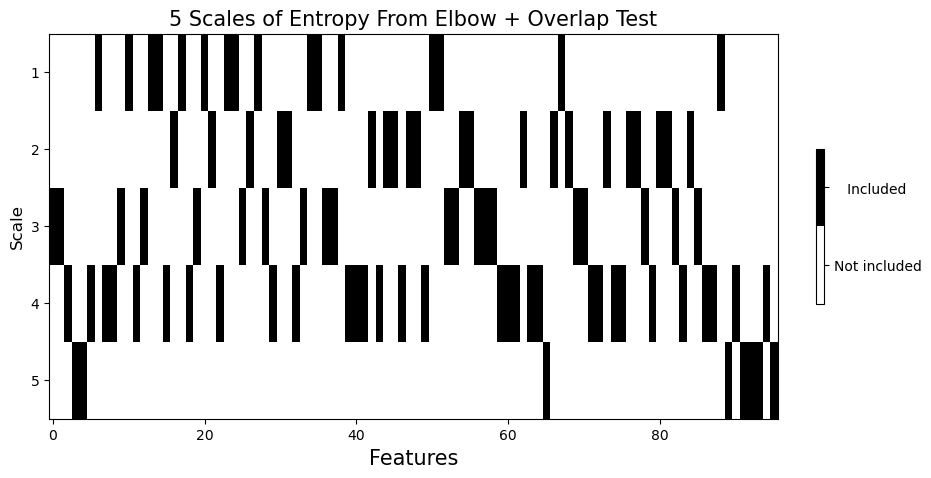

In [120]:
if Experiment==2:
    ## it is better to visualize partition map as image silhouettes:
    P_map = Overlap_Partition_Map
    num_part = len(P_map)
    fig,ax = plt.subplots(1,num_part, figsize=(15,3))
    for p in range(0, num_part):
        ax[p].imshow(P_map[p].reshape(28,28), cmap = "binary", aspect = 'auto')
        ax[p].set_title(f"Scale-{p+1}")
    plt.show()


else:
    plt.figure(figsize=(10,5))
    img = plt.imshow(Overlap_Partition_Map, cmap = 'binary', aspect='auto')
    plt.title(f"{len(Overlap_Partition_Map)} Scales of Entropy From Elbow + Overlap Test", fontsize = 15)
    plt.xlabel("Features", fontsize = 15)
    plt.ylabel("Scale", fontsize = 12)
    plt.yticks(range(0, len(Overlap_Partition_Map)), range(1, len(Overlap_Partition_Map)+1))
    cbar = plt.colorbar(img, boundaries=[-0.5, 0.5, 1.5], ticks=[0, 1], fraction = 0.01)
    cbar.set_ticklabels(['Not included', '   Included'])

    plt.show()

In [121]:
### Plotting other results from JF Bootstrap and Overlap test
GVF_Array = pd.DataFrame(GVF_Array)
## mean and deviations of GVF for each scale:
Mean_GVF_Array =GVF_Array.mean()
Dev_GVF_Array =GVF_Array.std()
Range = np.arange(Smallest_num_scales_tested, Largest_num_scales_tested+1, 1)

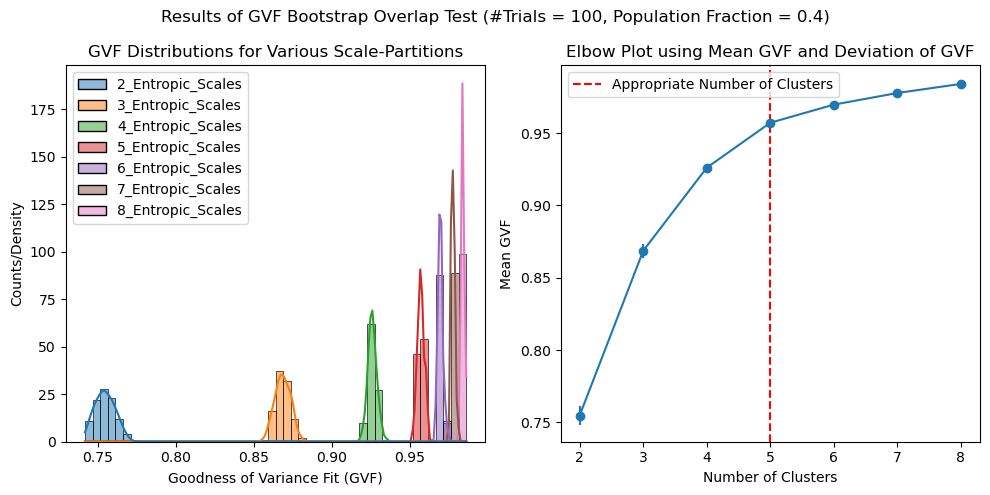

In [122]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
##------
sns.histplot(ax=ax[0],data=GVF_Array, kde=True, bins =50)
ax[0].set_xlabel("Goodness of Variance Fit (GVF)")
ax[0].set_ylabel ("Counts/Density")
ax[0].set_title("GVF Distributions for Various Scale-Partitions")
##-------
ax[1].errorbar(x = Range, y = Mean_GVF_Array, yerr=Dev_GVF_Array, marker="o")
ax[1].axvline(x= num_scales, color = "r", linestyle= "dashed", label = "Appropriate Number of Clusters")
ax[1].legend()
ax[1].set_title("Elbow Plot using Mean GVF and Deviation of GVF")
ax[1].set_xlabel("Number of Clusters")
ax[1].set_ylabel("Mean GVF")
plt.suptitle(f"Results of GVF Bootstrap Overlap Test (#Trials = {Num_Trials}, Population Fraction = {Proportion_of_Population_used})")
plt.tight_layout()
plt.show()


## Using KDE to Construct The Partition Map:

    - To do so, first we perform a bootstrap to compute entropy across various subsampling of the data
    - Ideally, the number of trials needs to be large to get a smooth distribution.
    - Otherwise, the peak window should be made larger to get rid of noisy fluctuations (fake peaks)

In [235]:
Data_fraction_used = 0.3
Num_Trials = 500

In [236]:
Entropy_Array, Mean_Entropy, Deviation_Entropy = Hierarchy.Entropy_Bootstrap(Data_fraction=Data_fraction_used , Number_of_Trials=Num_Trials)

100%|██████████| 500/500 [01:16<00:00,  6.55it/s]


In [237]:
min_val = (np.min(Mean_GVF_Array)) - 5* np.max(Dev_GVF_Array)
max_val = np.max(Mean_GVF_Array) + 5*np.max(Dev_GVF_Array)
X_range = np.linspace(min_val, max_val, 100)

In [245]:
KDE_Scales = KDE_Peak_Finder(Mean_Entropy, Deviation_Entropy, X_Range=X_range, peak_height_cutoff=0.2)

Range given is not sufficient. Redefining


Number of Input Pdfs= 96
Number of Peaks Found= 5
Peak 0 --> 16 Point(s) Assigned: [ 6 10 13 14 17 20 23 24 27 34 35 38 50 51 67 88]
Peak 1 --> 13 Point(s) Assigned: [16 21 26 45 47 54 55 66 68 76 77 80 81]
Peak 2 --> 15 Point(s) Assigned: [ 0  9 30 31 37 42 44 48 56 57 58 62 73 84 85]
Peak 3 --> 43 Point(s) Assigned: [ 1  2  5  7  8 11 12 15 18 19 22 25 28 29 32 33 36 40 41 43 46 49 52 53
 59 60 61 63 64 69 70 71 72 74 75 78 79 82 83 86 87 90 94]
Peak 4 --> 9 Point(s) Assigned: [ 3  4 39 65 89 91 92 93 95]


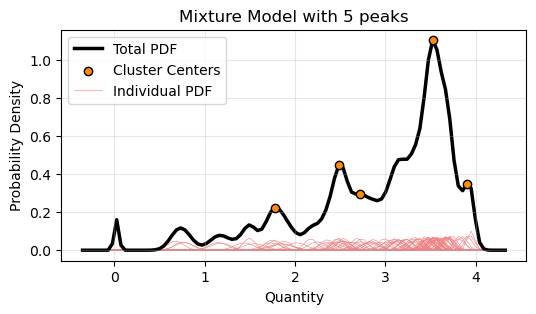

In [246]:
KDE_Scales.Results()

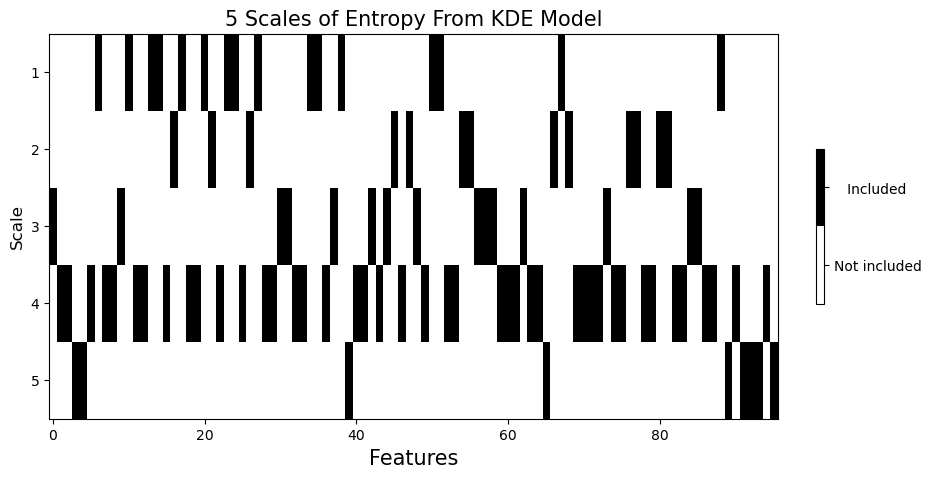

In [248]:
if Experiment==2:
    ## it is better to visualize MNIST partition map as image silhouettes:
    P_map = KDE_Scales.Partition_Map
    num_part = len(P_map)
    fig,ax = plt.subplots(1,num_part, figsize=(15,3))
    for p in range(0, num_part):
        ax[p].imshow(P_map[p].reshape(28,28), cmap = "binary", aspect = 'auto')
        ax[p].set_title(f"Scale-{p+1}")
else:
    KDE_Scales.Partition_Plotter()